In [ ]:
#Import libraries
import kagglehub
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error as MSE
import os
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier as HGBClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

In [ ]:
#loading/defining dataset
path = kagglehub.dataset_download("thashmiladewmini/squat-exercise-pose-dataset")

#show file in the directory
print(os.listdir(path))

#show file im actually looking for
print(os.listdir(os.path.join(path, "squat_dataset")))

#finally actually grabbing out file
data = pd.read_csv(
    os.path.join(path, "squat_dataset", "squat_features_augmented.csv"))

#making sure we got all the values written so nothing missing
print(data.isnull().sum())

#seeing what we're working with
print(data.info())

#setting our X and y for training the model
X = data.drop(columns=['video_file', 'label', 'frame'])
y = data['label']

#seeing what the data looks like
data.head(6)

100%|██████████| 2.27M/2.27M [00:00<00:00, 26.3MB/s]

Extracting files...


['squat_dataset']
['squat_features_augmented.csv', 'README.md']
left_knee_angle       0
right_knee_angle      0
left_hip_angle        0
right_hip_angle       0
left_ankle_angle      0
right_ankle_angle     0
spine_angle           0
torso_lean            0
left_knee_lateral     0
right_knee_lateral    0
symmetry_score        0
hip_depth             0
video_file            0
frame                 0
label                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47442 entries, 0 to 47441
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   left_knee_angle     47442 non-null  float64
 1   right_knee_angle    47442 non-null  float64
 2   left_hip_angle      47442 non-null  float64
 3   right_hip_angle     47442 non-null  float64
 4   left_ankle_angle    47442 non-null  float64
 5   right_ankle_angle   47442 non-null  float64
 6   spine_angle         47442 non-null  float64
 7   torso_le

,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,left_ankle_angle,right_ankle_angle,spine_angle,torso_lean,left_knee_lateral,right_knee_lateral,symmetry_score,hip_depth,video_file,frame,label
0,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,0
1,132.223949,116.930256,164.205496,146.066398,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,1
2,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,139.120795,108.975838,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,2
3,102.034287,83.887751,149.682786,141.059426,77.30243,70.434401,149.682786,95.286652,0.121875,0.140702,26.767481,0.444815,co1.mp4,0,3
4,120.254411,102.110289,149.682786,141.059426,101.23405,84.996304,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,4
5,133.244513,102.797361,150.187850,135.021836,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,5


In [ ]:

#setting data into train/test splits
#change values for test_size to find out the best amount for regression
#random_state doesn't matter, just a shuffle config
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#setting up standard scaler, which is basically somehting that makes sure all the data looks good for processing
#scaler = StandardScaler()
#scaling the x_train
#X_train = scaler.fit_transform(X_train)
#scaling the x_test
#X_test = scaler.transform(X_test)


In [ ]:

#make ur model, experiment with models for this one


#BASIC LOGISTIC REGRESSION CLASSIFIER
modelLR = LogisticRegression(
    C=1.0,
    penalty='l2',
    random_state=42
    )

In [ ]:
#MORE ADVANCED RANDOM FOREST CLASSIFIER
modelRFC = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42)

In [ ]:

# GRADIENT BOOSTING CLASSIFIER, SLOW BUT ACCURATE
modelGBC = GradientBoostingClassifier(
    learning_rate=0.075,
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42)


In [ ]:
# XGBClassifier (EXTREME GRADIENT BOOSTING CLASSIFIER)

modelXGB = XGBClassifier(
    n_estimators=600,
    learning_rate=0.055,
    max_depth=6,
    objective='multi:softprob',
    num_class=6,
    random_state=42,
    #colsample_bytree=0.8,
    min_split_loss=0.2)

In [ ]:
# AdaBoostClassifier, weakest model
modelADA = AdaBoostClassifier(
    n_estimators=500,
    learning_rate=0.5,
    random_state=42)

# AdaBoostClassifier, somewhat strong but not nearly good enough
modelADA2 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=6, random_state=42),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42)

In [ ]:
modelHGB = HGBClassifier(
    max_iter=400,
    learning_rate=0.05,
    max_depth=6,
    l2_regularization=1.5,
    max_features=0.8,
    early_stopping=True,
    random_state=42)

In [ ]:
#LightGradientBoostingClassifier, probably one of the strongest ones for this dataset

modelLGB = LGBMClassifier(
    boosting_type='gbdt',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=45,
    max_depth=7,
    min_child_samples=15,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

In [ ]:
modelfirst="modelLGB"
modelsecond="modelXGB"

#using LogisticRegression to be the model of the StackClassifier
meta_referee = LogisticRegression(
    max_iter=1000,
    class_weight={0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.3},
    random_state=42,
    verbose=0)


#making the stacking classifier
modelSTK = StackingClassifier(
    estimators=[
      ('model1', globals()[modelfirst]),
      ('model2', globals()[modelsecond])],

    final_estimator=meta_referee,
    cv=3,
    n_jobs=-1,
    verbose=0)

In [ ]:
#This is made to check out the models to record their train/test accuracy
typeofmodel = input("What model are you using? \nEg. LR, RFC, GBC, XGB, ADA, ADA2, HGB, LGB, STK \n")
typeofmodel = typeofmodel.upper()
model = "model" + typeofmodel
#the try function checks to make sure the model actualyl has the model in it.
try:
  model = globals()[model] #globals() looks for a variable with the same name as model, in this case our function
except KeyError:
  print(f'Model "{model}" does not exist!') #if the omdel does not exist prevents an error from coming up
else:
  model.fit(X_train,y_train) #if the model exists then train and test
  y_pred = model.predict(X_test)
  print("Train accuracy:", model.score(X_train, y_train))
  print("Test accuracy:", model.score(X_test, y_test))


What model are you using? 
Eg. LR, RFC, GBC, XGB, ADA, ADA2, HGB, LGB, STK 
XGB
Train accuracy: 0.973757015255711
Test accuracy: 0.9342396459057857


In [ ]:
#making the model equal a specific model to easily integrate
model = modelSTK

#train the model based on the training data
model.fit(X_train, y_train)

#use the test set to make sure the model actually works
y_pred = model.predict(X_test)


In [ ]:
#giving the accuracy metrics
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


#print the values of the train/test accuracy
#high disparity means overfitting basically
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))
print("\nRMSE:", math.sqrt(MSE(y_test, y_pred)))

0.9579513120455264
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1546
           1       0.96      0.96      0.96      1553
           2       0.98      0.97      0.97      1576
           3       0.99      0.98      0.99      1538
           4       0.99      0.98      0.98      1676
           5       0.92      0.89      0.90      1600

    accuracy                           0.96      9489
   macro avg       0.96      0.96      0.96      9489
weighted avg       0.96      0.96      0.96      9489

Train accuracy: 0.9968645429873791
Test accuracy: 0.9579513120455264

RMSE: 0.809757128805276


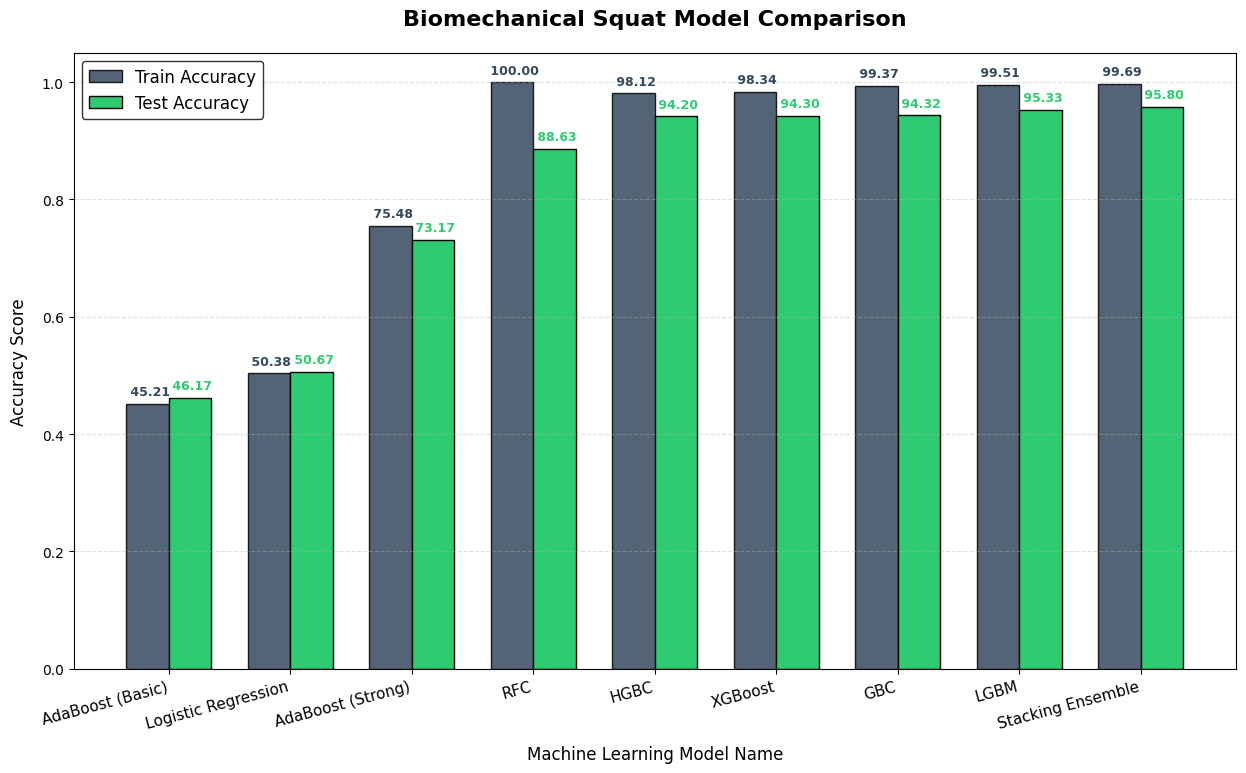

In [ ]:
#making a list of the models to later add into the graph
mymodels = [
    "AdaBoost (Basic)",
    "Logistic Regression",
    "AdaBoost (Strong)",
    "RFC",
    "HGBC",
    "XGBoost",
    "GBC",
    "LGBM",
    "Stacking Ensemble"
]

#these are the train/test values that correspond to their specific model respectively
train_acc = [0.4521, 0.5038, 0.7548, 1.0000, 0.9812, 0.9834, 0.9937, 0.9951, 0.9969]
test_acc  = [0.4617, 0.5067, 0.7317, 0.8863, 0.9420, 0.9430, 0.9432, 0.9533, 0.9580]

#makes it a bar graph whose height is as tall as the accuracy
x = np.arange(len(mymodels))
width = 0.35

#size of the graph
fig, ax = plt.subplots(figsize=(15, 8))

#making the bars for the graph
train = ax.bar(x - width/2, train_acc, width, label='Train Accuracy', color='#34495e', edgecolor='black', alpha=0.85)
test = ax.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#2ecc71', edgecolor='black')

#making the title and the labels for the axes.
ax.set_title('Biomechanical Squat Model Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Machine Learning Model Name', fontsize=12, labelpad=10)
ax.set_ylabel('Accuracy Score', fontsize=12, labelpad=10)

#giving the legend for the graph, telling what the colors are for train vs test basically
ax.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='Black')
ax.grid(axis='y', linestyle='--', alpha=0.4)

#makes sure the model names actually come instead of numbers
ax.set_xticks(x)
ax.set_xticklabels(mymodels, rotation=15, ha='right', fontsize=11)

#basically it writes the height (accuracy) of the model above the bar
def label(rects, graphcolor):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f' {height*100:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, color=graphcolor, fontweight='bold')

#putting accuracy values for train and test aboveit
label(train, "#34495e")
label(test, "#2ecc71")

plt.show()


> high change from changing Logistic Regression to RandomForestClassifer
> negligible change from doubling n_estimators
> some change from adding to max_depth
> negligible change from slight increase to min_samples_leaf
> RandomForestClassifier had overfitting of around 12%
> huge change from RandomForestClassifier to GradientBoostingClassifier, although slight overfitting
> negligible accuracy change from GradientBoostingClassifier, however significant time reduction (17min - 34sec)
> negligible changes from adding in the min_split_loss value
> StandardScaler generally causes the model to be slightly less accurate and more overfitted to the training data.
> Class 5 had the most missed predictions (lowest recall) but high prediction accuracy when it was actually 5


#Model Accuracies
---------------------------------------------------------------------
XGBoost (No StandardScaler)
Train accuracy: 0.9834268700761468
Test accuracy: 0.9429866160817789
---------------------------------------------------------------------
#LESS OVERFITTING
XGBoost (Yes StandardScaler)
Train accuracy: 0.9827945089979712
Test accuracy: 0.9416166087048161
---------------------------------------------------------------------
#MORE OVERFITTING
---------------------------------------------------------------------
AdaBoostClassifier v1 (Basic):
Train accuracy: 0.45211182251732407
Test accuracy: 0.4616924860364633
---------------------------------------------------------------------
#The worst model so far. Horrible performance
---------------------------------------------------------------------
AdaBoostClassifier v2 (Stronger):
Train accuracy: 0.7548019919373963
Test accuracy: 0.731689324480978
---------------------------------------------------------------------
#More accurate than the base model but still bad
---------------------------------------------------------------------
LightGradientBoostingClassifier:
Train accuracy: 0.9951255500223961
Test accuracy: 0.9533143640004216
---------------------------------------------------------------------
#Slight overfitting but most accurate so far
---------------------------------------------------------------------
GradientBoostingClassifier:
Train accuracy: 0.9936763892182436
Test accuracy: 0.9431973864474655
---------------------------------------------------------------------
#Good but overfitting
---------------------------------------------------------------------
LogisticRegression:
Train accuracy: 0.5038073406581824
Test accuracy: 0.5066919591105491
---------------------------------------------------------------------
#Very poor accuracy, basically like guessing
---------------------------------------------------------------------
RandomForestClassifier:
Train accuracy: 1.0
Test accuracy: 0.8862893877120877
---------------------------------------------------------------------
#Pretty good but its overfitting too much
---------------------------------------------------------------------
HistGradientBoostingClassifier
Train accuracy: 0.9812136063025321
Test accuracy: 0.9420381494361892
---------------------------------------------------------------------
#Really good, about as good as XGBoost
---------------------------------------------------------------------
StackingClassifier:
Train accuracy: 0.9968645429873791
Test accuracy: 0.9579513120455264
--------------------------------------------------------------------
#MOST ACCURATE